# UFC Fight Prediction — Data Preparation

Load, clean, and engineer features from UFC fight data to prepare a training set
for a binary classifier that predicts the winner of a matchup between two fighters.

**Data snapshot:** 2026-03-18

**Output:** Prepared CSVs saved to `data/2026-03-18/prepared/` for use in the model training notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data/2026-03-18")
sns.set_theme(style="whitegrid")

In [2]:
fighters = pd.read_csv(DATA_DIR / "raw" / "fighters.csv")
fights = pd.read_csv(DATA_DIR / "raw" / "fights.csv", parse_dates=["event_date"])
fight_stats = pd.read_csv(DATA_DIR / "raw" / "fight_stats.csv")

In [3]:
dfs = {"fighters": fighters, "fights": fights, "fight_stats": fight_stats}
for name, df in dfs.items():
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Dtypes:\n{df.dtypes}\n")
    display(df.head(3))
    print()

=== fighters ===
Shape: (2651, 19)
Dtypes:
fighter_id         str
name               str
nickname           str
wins             int64
losses           int64
ties           float64
height_in      float64
weight_lb      float64
reach_in       float64
stance             str
age            float64
slpm           float64
str_acc_dec    float64
sapm           float64
str_def_dec    float64
td_avg         float64
td_acc_dec     float64
td_def_dec     float64
sub_avg        float64
dtype: object



,fighter_id,name,nickname,wins,losses,ties,height_in,weight_lb,reach_in,stance,age,slpm,str_acc_dec,sapm,str_def_dec,td_avg,td_acc_dec,td_def_dec,sub_avg
0,46d0a888d87d91ac,Abu Azaitar,Captain Morocco,14,4,1.0,69.0,185.0,76.0,Orthodox,40.0,4.38,0.43,4.32,0.51,1.00,0.37,0.42,0.0
1,394f55ebca199124,Ivan Salaverry,NaN,14,9,0.0,72.0,185.0,NaN,Orthodox,55.0,3.01,0.47,1.19,0.76,0.49,0.18,0.36,2.5
2,03f982ca3735070c,Walt Harris,The Big Ticket,13,10,NaN,77.0,250.0,77.0,Southpaw,42.0,3.05,0.39,3.33,0.54,0.29,0.28,0.70,0.1



=== fights ===
Shape: (8586, 5)
Dtypes:
fight_id                   str
event_date      datetime64[us]
weight_class               str
method                     str
round                    int64
dtype: object



,fight_id,event_date,weight_class,method,round
0,f030febede41c661,2026-03-07,Lightweight,U-DEC,5
1,d564db29997e1371,2026-03-07,Middleweight,U-DEC,3
2,bed89a91da9d04c1,2026-03-07,Bantamweight,U-DEC,3



=== fight_stats ===
Shape: (17130, 9)
Dtypes:
fight_id           str
fighter_id         str
result             str
sig_strikes      int64
sig_attempted    int64
td               int64
td_attempted     int64
sub_attempts     int64
control_time     int64
dtype: object



,fight_id,fighter_id,result,sig_strikes,sig_attempted,td,td_attempted,sub_attempts,control_time
0,f02c0adc4ae629c6,519e4fe37ce9ff75,W,22,55,0,0,0,0
1,f02c0adc4ae629c6,511e82663651438d,L,27,76,0,0,0,0
2,6a4738656c493ee9,d1c65d2cf2925ddd,W,2,6,0,0,0,0


In [4]:
for name, df in dfs.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f"=== {name} — columns with nulls ===")
        print(nulls)
        print()
    else:
        print(f"=== {name} — no nulls ===")

=== fighters — columns with nulls ===
nickname     918
ties         379
height_in     13
weight_lb     10
reach_in     638
stance        67
age           88
dtype: int64

=== fights — no nulls ===
=== fight_stats — no nulls ===


In [5]:
print("Duplicate fighter_ids:", fighters["fighter_id"].duplicated().sum())
print("Duplicate fight_ids:", fights["fight_id"].duplicated().sum())
print()
rows_per_fight = fight_stats.groupby("fight_id").size().value_counts().sort_index()
print("Rows per fight_id in fight_stats:")
print(rows_per_fight)

Duplicate fighter_ids: 0
Duplicate fight_ids: 0

Rows per fight_id in fight_stats:
2    8565
Name: count, dtype: int64


## Data Cleaning

- Drop fights without a decisive W/L outcome (draws, no-contests, DQs, overturned)
- Validate data types and referential integrity
- Report missing physical measurements (imputed later during feature engineering)

In [6]:
print("Result distribution in fight_stats:")
print(fight_stats["result"].value_counts())
print()

# Keep only fights where there is exactly one W and one L
w_fights = fight_stats[fight_stats["result"] == "W"]["fight_id"]
l_fights = fight_stats[fight_stats["result"] == "L"]["fight_id"]
valid_fight_ids = set(w_fights) & set(l_fights)

fight_stats_clean = fight_stats[fight_stats["fight_id"].isin(valid_fight_ids)].copy()
fights_clean = fights[fights["fight_id"].isin(valid_fight_ids)].copy()

# Drop problematic methods
drop_methods = {"Overturned", "CNC", "DQ", "Other"}
fights_clean = fights_clean[~fights_clean["method"].isin(drop_methods)]
valid_fight_ids = set(fights_clean["fight_id"])
fight_stats_clean = fight_stats_clean[fight_stats_clean["fight_id"].isin(valid_fight_ids)].copy()

print(f"Fights after cleaning: {len(fights_clean)} (dropped {len(fights) - len(fights_clean)})")
print(f"Fight stats rows after cleaning: {len(fight_stats_clean)}")

Result distribution in fight_stats:
result
W     8414
L     8414
NC     178
D      124
Name: count, dtype: int64

Fights after cleaning: 8391 (dropped 195)
Fight stats rows after cleaning: 16782


In [7]:
phys_cols = ["height_in", "weight_lb", "reach_in", "stance", "age"]
print("Missing physical measurements in fighters:")
for col in phys_cols:
    n_missing = fighters[col].isnull().sum()
    pct = n_missing / len(fighters) * 100
    print(f"  {col}: {n_missing} ({pct:.1f}%)")

Missing physical measurements in fighters:
  height_in: 13 (0.5%)
  weight_lb: 10 (0.4%)
  reach_in: 638 (24.1%)
  stance: 67 (2.5%)
  age: 88 (3.3%)


In [8]:
numeric_cols = ["sig_strikes", "sig_attempted", "td", "td_attempted", "sub_attempts", "control_time"]
for col in numeric_cols:
    assert pd.api.types.is_numeric_dtype(fight_stats_clean[col]), f"{col} is not numeric"
print("All fight_stats numeric columns validated.")

All fight_stats numeric columns validated.


In [9]:
fs_fighter_ids = set(fight_stats_clean["fighter_id"].unique())
known_fighter_ids = set(fighters["fighter_id"].unique())
orphaned = fs_fighter_ids - known_fighter_ids
print(f"Fighter IDs in fight_stats but not in fighters: {len(orphaned)}")
print("(These fighters will have NaN profile features, handled during imputation.)")

Fighter IDs in fight_stats but not in fighters: 0
(These fighters will have NaN profile features, handled during imputation.)


## Exploratory Data Analysis

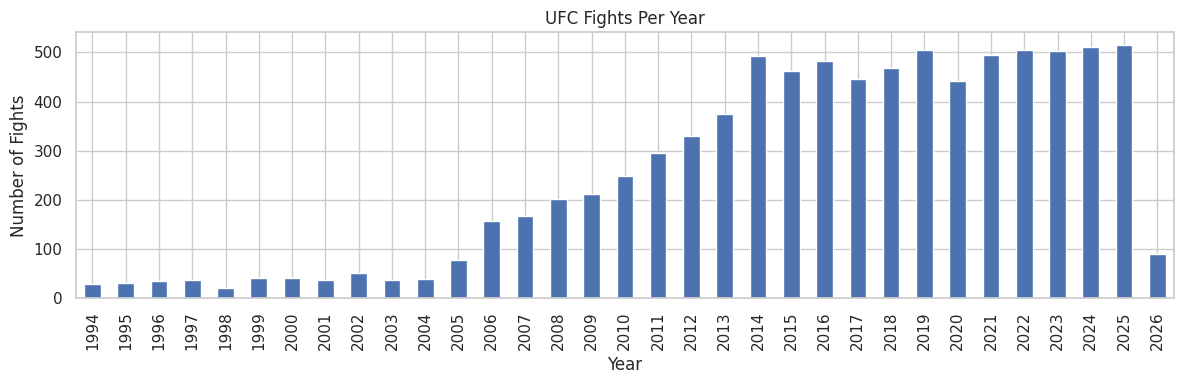

In [10]:
year_counts = fights_clean["event_date"].dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 4))
year_counts.plot(kind="bar", ax=ax)
ax.set_title("UFC Fights Per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Fights")
plt.tight_layout()
plt.show()

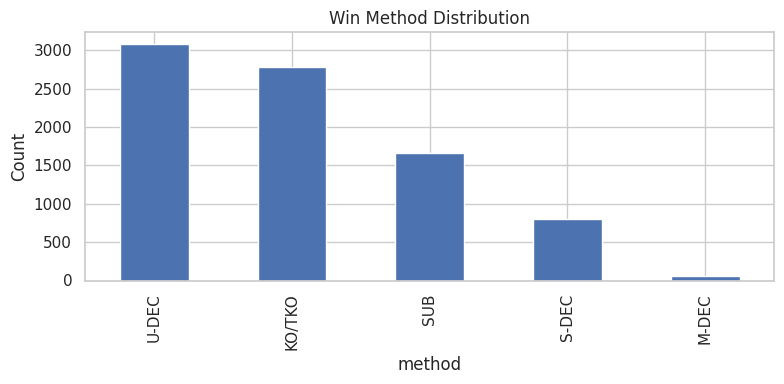

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
fights_clean["method"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Win Method Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

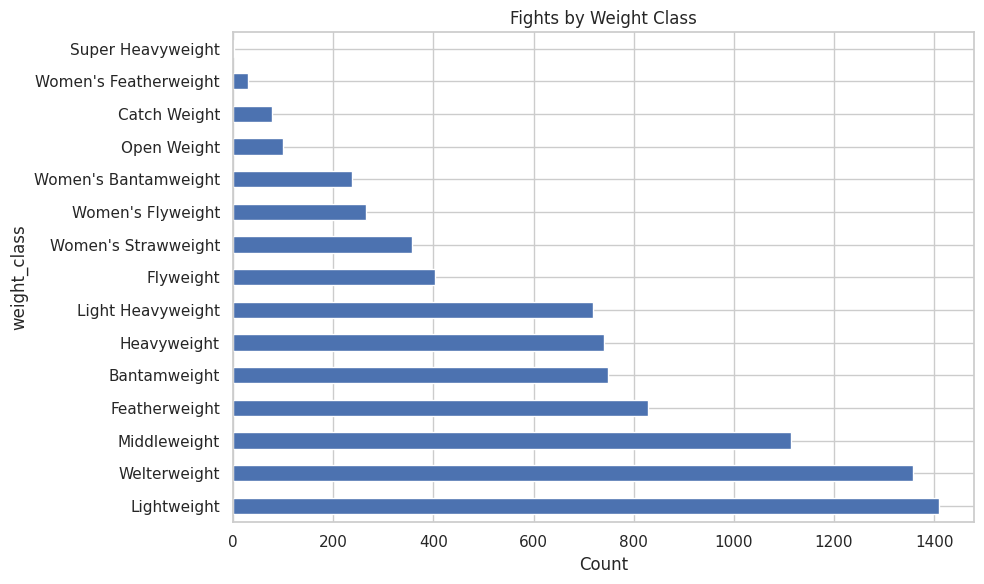

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
fights_clean["weight_class"].value_counts().plot(kind="barh", ax=ax)
ax.set_title("Fights by Weight Class")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

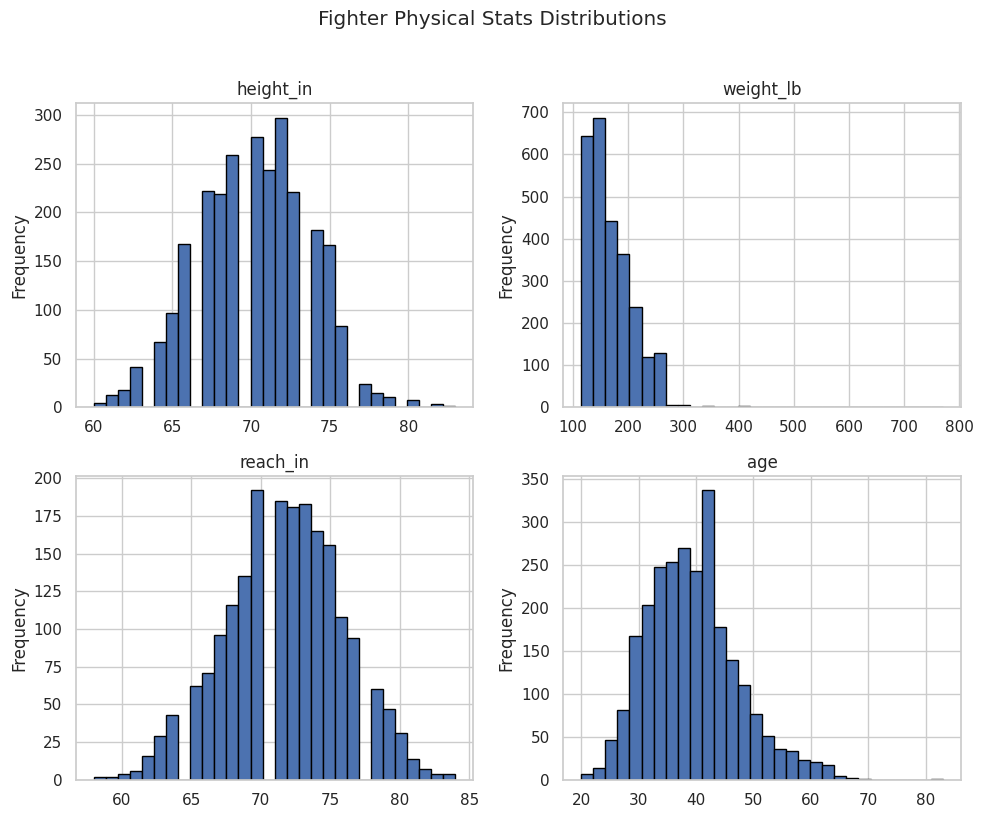

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, ["height_in", "weight_lb", "reach_in", "age"]):
    fighters[col].dropna().plot(kind="hist", bins=30, ax=ax, edgecolor="black")
    ax.set_title(col)
plt.suptitle("Fighter Physical Stats Distributions", y=1.02)
plt.tight_layout()
plt.show()

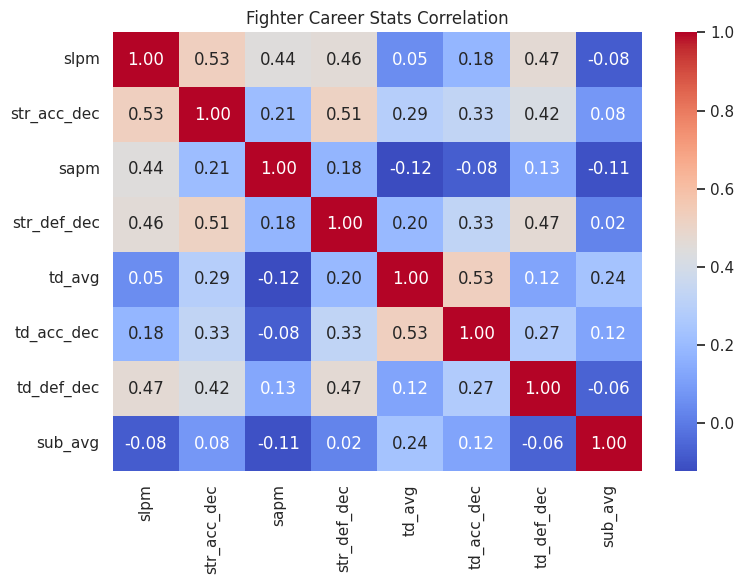

In [14]:
career_stats = ["slpm", "str_acc_dec", "sapm", "str_def_dec", "td_avg", "td_acc_dec", "td_def_dec", "sub_avg"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(fighters[career_stats].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Fighter Career Stats Correlation")
plt.tight_layout()
plt.show()

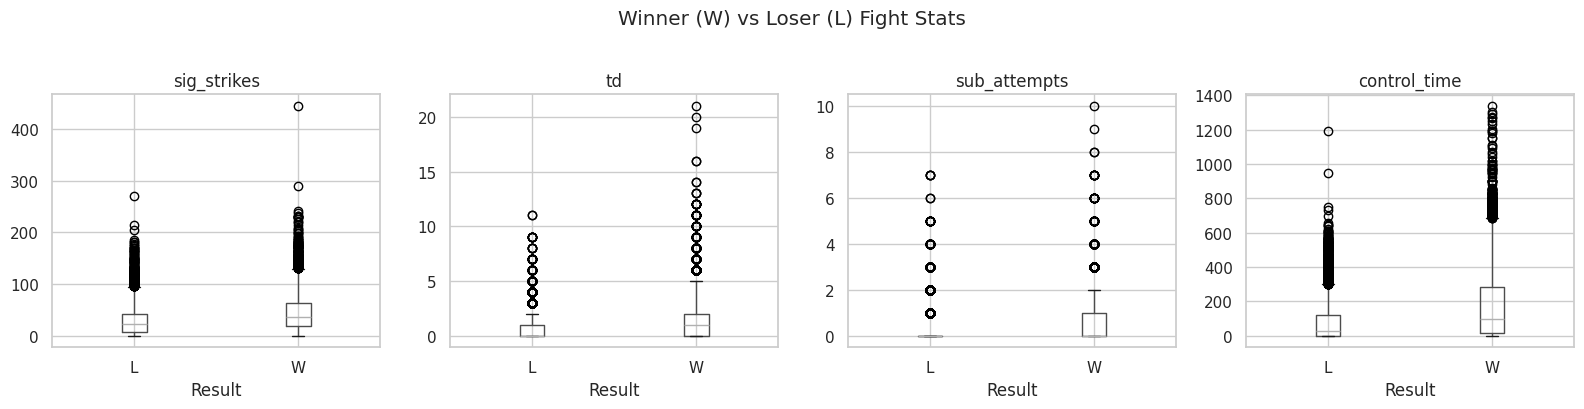

In [15]:
compare_cols = ["sig_strikes", "td", "sub_attempts", "control_time"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, compare_cols):
    fight_stats_clean.boxplot(column=col, by="result", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Result")
plt.suptitle("Winner (W) vs Loser (L) Fight Stats", y=1.02)
plt.tight_layout()
plt.show()

**Key takeaway:** Fight-level stats (sig_strikes, control_time, etc.) clearly distinguish winners from losers, but these are *outcomes* of the fight. For prediction, we must use only **pre-fight information**: fighter profiles and historical aggregates computed from prior fights only.

## Feature Engineering

**Strategy:**
- Each training sample = one fight, with fighters randomly assigned as A and B
- Features come from fighter profiles and historical fight performance (only fights *before* the current one)
- Random A/B assignment ensures ~50/50 target balance (no positional bias)
- Target: 1 if Fighter A wins, 0 if Fighter B wins

In [16]:
# Build matchup table: one row per fight with winner and loser
winners = (
    fight_stats_clean[fight_stats_clean["result"] == "W"][["fight_id", "fighter_id"]]
    .rename(columns={"fighter_id": "winner_id"})
)
losers = (
    fight_stats_clean[fight_stats_clean["result"] == "L"][["fight_id", "fighter_id"]]
    .rename(columns={"fighter_id": "loser_id"})
)
matchups = (
    winners
    .merge(losers, on="fight_id")
    .merge(fights_clean[["fight_id", "event_date", "weight_class"]], on="fight_id")
)
print(f"Matchups: {len(matchups)}")
matchups.head()

Matchups: 8391


,fight_id,winner_id,loser_id,event_date,weight_class
0,f02c0adc4ae629c6,519e4fe37ce9ff75,511e82663651438d,2026-03-07,Lightweight
1,6a4738656c493ee9,d1c65d2cf2925ddd,1e719d4b676dc19a,2026-03-07,Middleweight
2,bed89a91da9d04c1,fe2babf95de24fb1,05339613bf8e9808,2026-03-07,Bantamweight
3,ecd16d14a138d7fb,d8c7c61b176e3994,86bace9e4ad85542,2026-03-07,Bantamweight
4,d564db29997e1371,4126a78111c0855a,d549cefc7c54ab78,2026-03-07,Middleweight


In [17]:
# Randomly assign fighters to A/B positions to avoid positional bias
rng = np.random.default_rng(42)
swap = rng.random(len(matchups)) > 0.5

matchups["fighter_a_id"] = np.where(swap, matchups["winner_id"], matchups["loser_id"])
matchups["fighter_b_id"] = np.where(swap, matchups["loser_id"], matchups["winner_id"])
matchups["target"] = np.where(matchups["fighter_a_id"] == matchups["winner_id"], 1, 0)
matchups = matchups.drop(columns=["winner_id", "loser_id"])

print(f"Target balance: {matchups['target'].mean():.3f} (should be ~0.5)")

Target balance: 0.496 (should be ~0.5)


In [18]:
# Compute historical features per fighter using only prior fights (expanding + shift)
fs = fight_stats_clean.merge(
    fights_clean[["fight_id", "event_date", "method"]], on="fight_id"
)
fs = fs.sort_values(["fighter_id", "event_date", "fight_id"]).reset_index(drop=True)

# Use vectorized cumulative ops with groupby instead of apply
grp = fs.groupby("fighter_id")

# Fight count per fighter (0-indexed: 0 for first fight)
fs["hist_fights"] = grp.cumcount()

# Cumulative wins/losses shifted by 1 (only prior fights)
fs["_is_win"] = (fs["result"] == "W").astype(int)
fs["_is_loss"] = (fs["result"] == "L").astype(int)
fs["hist_wins"] = grp["_is_win"].cumsum().shift(1, fill_value=0)
# Re-align after shift: ensure shift is within groups
fs["hist_wins"] = grp["_is_win"].transform(lambda x: x.cumsum().shift(1, fill_value=0))
fs["hist_losses"] = grp["_is_loss"].transform(lambda x: x.cumsum().shift(1, fill_value=0))
fs["hist_win_rate"] = fs["hist_wins"] / fs["hist_fights"].replace(0, np.nan)

# Strike accuracy from prior fights
fs["_strike_acc"] = fs["sig_strikes"] / fs["sig_attempted"].replace(0, np.nan)
fs["hist_strike_acc"] = grp["_strike_acc"].transform(lambda x: x.expanding().mean().shift(1))

# Takedown accuracy from prior fights
fs["_td_acc"] = fs["td"] / fs["td_attempted"].replace(0, np.nan)
fs["hist_td_acc"] = grp["_td_acc"].transform(lambda x: x.expanding().mean().shift(1))

# Submission and control averages from prior fights
fs["hist_sub_avg"] = grp["sub_attempts"].transform(lambda x: x.expanding().mean().shift(1))
fs["hist_ctrl_avg"] = grp["control_time"].transform(lambda x: x.expanding().mean().shift(1))

# Finish rate: fraction of prior wins by KO/TKO or SUB
fs["_is_finish_win"] = ((fs["result"] == "W") & (fs["method"].isin(["KO/TKO", "SUB"]))).astype(int)
fs["_hist_finish_wins"] = grp["_is_finish_win"].transform(lambda x: x.cumsum().shift(1, fill_value=0))
fs["hist_finish_rate"] = fs["_hist_finish_wins"] / fs["hist_wins"].replace(0, np.nan)

# Clean up temp columns
fighter_hist = fs.drop(columns=[c for c in fs.columns if c.startswith("_")])

print(f"Fighter history rows: {len(fighter_hist)}")
fighter_hist[["fighter_id", "fight_id", "hist_fights", "hist_wins", "hist_win_rate"]].head(10)

Fighter history rows: 16782


,fighter_id,fight_id,hist_fights,hist_wins,hist_win_rate
0,001eb2ab0f30e7ea,0e8599eca8ccfa32,0,0,NaN
1,002ca196477ce572,bc01ce748a5723df,0,0,NaN
2,002ca196477ce572,0e3af9b5e1b3ae80,1,0,0.000000
3,003d82fa384ca1d0,0bcb04163f8d8ead,0,0,NaN
4,003d82fa384ca1d0,e2abba69c3371618,1,0,0.000000
5,0052de90691d4a93,f4f5049e789b7716,0,0,NaN
6,0052de90691d4a93,f9536ea60551b840,1,0,0.000000
7,0052de90691d4a93,5ea39e0fc3b64e83,2,1,0.500000
8,0052de90691d4a93,933cf2674503c63d,3,2,0.666667
9,0052de90691d4a93,65c1ca715dfdbe05,4,3,0.750000


In [19]:
# Slim to join columns
hist_cols = ["fight_id", "fighter_id", "hist_fights", "hist_wins", "hist_losses",
             "hist_win_rate", "hist_strike_acc", "hist_td_acc",
             "hist_sub_avg", "hist_ctrl_avg", "hist_finish_rate"]
fighter_hist_slim = fighter_hist[hist_cols].copy()

In [20]:
# Merge fighter profile features for both fighters
profile_cols = ["fighter_id", "height_in", "weight_lb", "reach_in", "stance", "age",
                "slpm", "str_acc_dec", "sapm", "str_def_dec",
                "td_avg", "td_acc_dec", "td_def_dec", "sub_avg"]

# Merge for fighter A
dataset = matchups.merge(
    fighters[profile_cols].rename(columns={c: f"{c}_a" for c in profile_cols if c != "fighter_id"}),
    left_on="fighter_a_id", right_on="fighter_id", how="left"
).drop(columns="fighter_id")

# Merge for fighter B
dataset = dataset.merge(
    fighters[profile_cols].rename(columns={c: f"{c}_b" for c in profile_cols if c != "fighter_id"}),
    left_on="fighter_b_id", right_on="fighter_id", how="left"
).drop(columns="fighter_id")

print(f"Dataset shape after profile merge: {dataset.shape}")

Dataset shape after profile merge: (8391, 32)


In [21]:
# Merge historical features for both fighters
hist_feature_cols = [c for c in hist_cols if c not in ("fight_id", "fighter_id")]

dataset = dataset.merge(
    fighter_hist_slim.rename(columns={c: f"{c}_a" for c in hist_feature_cols}),
    left_on=["fight_id", "fighter_a_id"], right_on=["fight_id", "fighter_id"], how="left"
).drop(columns="fighter_id")

dataset = dataset.merge(
    fighter_hist_slim.rename(columns={c: f"{c}_b" for c in hist_feature_cols}),
    left_on=["fight_id", "fighter_b_id"], right_on=["fight_id", "fighter_id"], how="left"
).drop(columns="fighter_id")

print(f"Dataset shape after history merge: {dataset.shape}")

Dataset shape after history merge: (8391, 50)


In [22]:
# Compute differential features (A - B) for all numeric feature pairs
diff_pairs = [
    "height_in", "weight_lb", "reach_in", "age",
    "slpm", "str_acc_dec", "sapm", "str_def_dec",
    "td_avg", "td_acc_dec", "td_def_dec", "sub_avg",
    "hist_fights", "hist_wins", "hist_losses", "hist_win_rate",
    "hist_strike_acc", "hist_td_acc", "hist_sub_avg", "hist_ctrl_avg",
    "hist_finish_rate",
]
for col in diff_pairs:
    dataset[f"{col}_diff"] = dataset[f"{col}_a"] - dataset[f"{col}_b"]

print(f"Dataset shape after diff features: {dataset.shape}")

Dataset shape after diff features: (8391, 71)


In [23]:
# Impute missing values

# 1. Physical stats: median within weight class, fallback to global median
phys_suffixed = [f"{c}_{s}" for c in ["height_in", "weight_lb", "reach_in", "age"] for s in ["a", "b"]]
for col in phys_suffixed:
    dataset[col] = dataset.groupby("weight_class")[col].transform(lambda x: x.fillna(x.median()))
    dataset[col] = dataset[col].fillna(dataset[col].median())

# 2. Historical count features: fill NaN with 0 (debut fighters)
hist_count_cols = [c for c in dataset.columns if any(
    c.startswith(p) for p in ["hist_fights_", "hist_wins_", "hist_losses_"]
)]
dataset[hist_count_cols] = dataset[hist_count_cols].fillna(0)

# 3. Historical rate/avg features: fill NaN with global median
hist_rate_cols = [c for c in dataset.columns if any(
    c.startswith(p) for p in ["hist_win_rate_", "hist_strike_acc_", "hist_td_acc_",
                              "hist_sub_avg_", "hist_ctrl_avg_", "hist_finish_rate_"]
)]
for col in hist_rate_cols:
    dataset[col] = dataset[col].fillna(dataset[col].median())

# 4. Career stats from fighter profile: fill NaN with 0
career_suffixed = [f"{c}_{s}" for c in ["slpm", "str_acc_dec", "sapm", "str_def_dec",
                                          "td_avg", "td_acc_dec", "td_def_dec", "sub_avg"]
                   for s in ["a", "b"]]
dataset[career_suffixed] = dataset[career_suffixed].fillna(0)

# 5. Recompute diff features after imputation
for col in diff_pairs:
    dataset[f"{col}_diff"] = dataset[f"{col}_a"] - dataset[f"{col}_b"]

# 6. Stance: fill NaN with "Unknown"
dataset["stance_a"] = dataset["stance_a"].fillna("Unknown")
dataset["stance_b"] = dataset["stance_b"].fillna("Unknown")

print("Missing values after imputation:")
remaining = dataset.isnull().sum()
remaining = remaining[remaining > 0]
print(remaining if len(remaining) > 0 else "None!")

Missing values after imputation:


None!


In [24]:
# Encode categorical variables

# Stance: one-hot encode for both fighters
dataset = pd.get_dummies(dataset, columns=["stance_a", "stance_b"], drop_first=True, dtype=int)

# Weight class: collapse rare classes, then one-hot encode
wc_counts = dataset["weight_class"].value_counts()
rare_classes = wc_counts[wc_counts < 50].index
dataset["weight_class"] = dataset["weight_class"].replace(rare_classes, "Other")
dataset = pd.get_dummies(dataset, columns=["weight_class"], drop_first=True, dtype=int)

print(f"Final dataset shape: {dataset.shape}")

Final dataset shape: (8391, 91)


In [25]:
# Verify zero nulls in feature columns
exclude_cols = {"fight_id", "fighter_a_id", "fighter_b_id", "event_date", "target"}
feature_cols = [c for c in dataset.columns if c not in exclude_cols]
null_counts = dataset[feature_cols].isnull().sum()
assert null_counts.sum() == 0, f"Found nulls:\n{null_counts[null_counts > 0]}"
print(f"Verified: {len(feature_cols)} feature columns, zero nulls.")

Verified: 86 feature columns, zero nulls.


## Final Dataset

**Temporal train/test split:** We split by `event_date` rather than randomly. The model trains on past fights and is tested on future fights, simulating real-world prediction. This prevents temporal data leakage.

In [26]:
cutoff = pd.Timestamp("2024-01-01")
train = dataset[dataset["event_date"] < cutoff].copy()
test = dataset[dataset["event_date"] >= cutoff].copy()

print(f"Train: {len(train)} samples ({train['event_date'].min().date()} to {train['event_date'].max().date()})")
print(f"Test:  {len(test)} samples ({test['event_date'].min().date()} to {test['event_date'].max().date()})")
print(f"Split ratio: {len(train) / len(dataset):.1%} train / {len(test) / len(dataset):.1%} test")
print(f"Target balance — Train: {train['target'].mean():.3f}, Test: {test['target'].mean():.3f}")

Train: 7275 samples (1994-03-11 to 2023-12-16)
Test:  1116 samples (2024-01-13 to 2026-03-14)
Split ratio: 86.7% train / 13.3% test
Target balance — Train: 0.495, Test: 0.498


In [27]:
X_train, y_train = train[feature_cols], train["target"]
X_test, y_test = test[feature_cols], test["target"]

print(f"Features: {len(feature_cols)}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Features: 86
X_train: (7275, 86), X_test: (1116, 86)


In [28]:
# Build fighter feature lookup (latest snapshot per fighter for prediction)
# Uses the most recent historical features + profile features for each fighter
latest_hist = fighter_hist.sort_values("event_date").groupby("fighter_id").last().reset_index()
fighter_features = fighters.merge(latest_hist[hist_cols[1:]], on="fighter_id", how="left")

# Fill NaN for fighters with no fight history
for col in hist_feature_cols:
    if "rate" in col or "acc" in col or "avg" in col:
        fighter_features[col] = fighter_features[col].fillna(fighter_features[col].median())
    else:
        fighter_features[col] = fighter_features[col].fillna(0)

print(f"Fighter features lookup: {fighter_features.shape}")
fighter_features.head()

Fighter features lookup: (2651, 28)


,fighter_id,name,nickname,wins,losses,ties,height_in,weight_lb,reach_in,stance,...,sub_avg,hist_fights,hist_wins,hist_losses,hist_win_rate,hist_strike_acc,hist_td_acc,hist_sub_avg,hist_ctrl_avg,hist_finish_rate
0,46d0a888d87d91ac,Abu Azaitar,Captain Morocco,14,4,1.0,69.0,185.0,76.0,Orthodox,...,0.0,2.0,1.0,1.0,0.500000,0.434075,0.5,0.000000,159.500000,0.0
1,394f55ebca199124,Ivan Salaverry,NaN,14,9,0.0,72.0,185.0,NaN,Orthodox,...,2.5,6.0,3.0,3.0,0.500000,0.474020,0.2,1.666667,76.500000,1.0
2,03f982ca3735070c,Walt Harris,The Big Ticket,13,10,NaN,77.0,250.0,77.0,Southpaw,...,0.1,13.0,6.0,7.0,0.461538,0.410267,0.0,0.076923,9.461538,1.0
3,9508cc6184cb2450,Eric McConico,NaN,10,4,1.0,72.0,185.0,77.0,Southpaw,...,0.0,2.0,1.0,1.0,0.500000,0.372863,0.4,0.000000,96.000000,0.0
4,d2f43cfaf8ca3560,Fernando Padilla,El Valiente,16,6,0.0,73.0,145.0,76.0,Orthodox,...,0.6,3.0,2.0,1.0,0.666667,0.531062,0.0,0.333333,18.666667,1.0


In [29]:
# Save prepared datasets
output_dir = DATA_DIR / "prepared"
output_dir.mkdir(exist_ok=True)

train[feature_cols + ["target"]].to_csv(output_dir / "train.csv", index=False)
test[feature_cols + ["target"]].to_csv(output_dir / "test.csv", index=False)
dataset.to_csv(output_dir / "matchups_full.csv", index=False)
fighter_features.to_csv(output_dir / "fighter_features.csv", index=False)

# Save feature column names for the model notebook
pd.Series(feature_cols).to_csv(output_dir / "feature_cols.csv", index=False, header=False)

print("Saved to", output_dir)
for f in sorted(output_dir.glob("*.csv")):
    print(f"  {f.name}: {f.stat().st_size / 1024:.0f} KB")

Saved to ../data/2026-03-18/prepared
  feature_cols.csv: 1 KB
  fighter_features.csv: 491 KB
  matchups_full.csv: 5171 KB
  test.csv: 629 KB
  train.csv: 4035 KB


## Summary

**Prepared datasets saved to `data/2026-03-18/prepared/`:**

| File | Contents |
|---|---|
| `train.csv` | Training features + target (fights before 2024) |
| `test.csv` | Test features + target (fights from 2024 onward) |
| `matchups_full.csv` | Full dataset with fight/fighter IDs for reference |
| `fighter_features.csv` | Latest feature snapshot per fighter (for prediction lookup) |
| `feature_cols.csv` | Ordered list of feature column names |

**Next step:** Open `fight_prediction_model.ipynb` to train a classifier and build the `predict_fight(fighter_a, fighter_b)` function.